<a href="https://colab.research.google.com/github/gerdoc-unir/M1-ACT-1/blob/alberto-tanh/Actividad1_MODAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from typing import AnyStr, List
import os
from pathlib import Path
import shutil
import random
import tensorflow as tf

from tensorflow import keras

In [3]:
!rm -fr images

In [4]:
#Declaración de variables
path_img_tar: AnyStr = 'images.tar.gz'
path_annotations_tar: AnyStr = 'annotations.tar.gz'
path_img: AnyStr = 'images'
path_annotations: AnyStr = 'annotations'
cat_label: AnyStr = 'cat'
dog_label: AnyStr = 'dog'
train_label: AnyStr = 'train'
validation_label: AnyStr = 'validation'
test_label: AnyStr = 'test'
carpeta_img: Path = None
archivos: List = None
carpeta_train: Path = None
carpeta_validation: Path = None
carpeta_test: Path = None
archivos_gatos: List = None
archivos_perros: List = None
proporciones: List[float] = [0.8, 0.1, 0.1]
gatos_train:List = []
gatos_validation:List = []
gatos_test: List = []
perros_train:List = []
perros_validation:List = []
perros_test: List = []
IMG_HEIGHT = 160
IMG_WIDTH = 160
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)
BATCH_SIZE = 32

In [5]:
#Validamos la separación sea correcta
assert abs(sum(proporciones) - 1.0) < 1e-9

In [6]:
#Descargando images
if not os.path.exists( path_img_tar ):
  print('Descargando imagenes...')
  os.system(f'wget -c https://www.robots.ox.ac.uk/~vgg/data/pets/data/{path_img_tar}')

#Descargando anotaciones
if not os.path.exists( path_annotations_tar ):
  print('Descargando anotaciones...')
  os.system(f'wget -c https://www.robots.ox.ac.uk/~vgg/data/pets/data/{path_annotations_tar}')

#Descompactando images
if os.path.exists( path_img_tar ) and not os.path.exists( path_img ):
  print('Descompactando imagenes...')
  os.system(f'tar -xf {path_img_tar}')
  carpeta_img: Path = Path( path_img )

#Descompactando anotaciones
if os.path.exists( path_annotations_tar ) and not os.path.exists( path_annotations ):
  print('Descompactando anotaciones...')
  os.system(f'tar -xf {path_annotations_tar}')


Descargando imagenes...
Descargando anotaciones...
Descompactando imagenes...
Descompactando anotaciones...


In [7]:
#Creación de carpetas
print('Creando carpetas de perros y gatos...')
if carpeta_img:
  archivos = list( carpeta_img.glob( "*.jpg" ) )
  print(f'Imagenes: {len(archivos)}' )
  carpeta_train = Path( f'{carpeta_img}/{train_label}' )
  carpeta_validation = Path( f'{carpeta_img}/{validation_label}' )
  carpeta_test = Path( f'{carpeta_img}/{test_label}' )
  carpetas: List[AnyStr] = [carpeta_train, carpeta_validation, carpeta_test]
  for carpeta in carpetas:
    if not os.path.exists( carpeta ):
      os.mkdir( carpeta )
      print( f'Creando {carpeta}' )
      os.mkdir( f'{carpeta}/{cat_label}' )
      print( f'Creando {carpeta}/{cat_label}' )
      os.mkdir( f'{carpeta}/{dog_label}' )
      print( f'Creando {carpeta}/{dog_label}' )

  if len( archivos ) > 0:
    archivos_gatos = []
    archivos_perros = []
    for archivo in archivos:
      if archivo.name[ 0 ].isupper( ):
        archivos_gatos.append( archivo )
      else:
        archivos_perros.append( archivo )
  if len( archivos_gatos ) > 0:
    print(f'Gatos: {len(archivos_gatos)}')
  if len( archivos_perros ) > 0:
    print(f'Perros: {len(archivos_perros)}')



Creando carpetas de perros y gatos...
Imagenes: 7390
Creando images/train
Creando images/train/cat
Creando images/train/dog
Creando images/validation
Creando images/validation/cat
Creando images/validation/dog
Creando images/test
Creando images/test/cat
Creando images/test/dog
Gatos: 2400
Perros: 4990


In [8]:
#Hacemos que se revuelvean los datos
random.seed( 42 )
random.shuffle( archivos_gatos )
random.shuffle( archivos_perros )

In [9]:
#Separamos los archivos en los distintos dataset
def dividir_archivos(archivos: List, proporciones: List[float]):
    total:int = len( archivos )
    limite_train:int = int(total * proporciones[0])
    limite_validation:int = limite_train + int(total * proporciones[1])
    train:List = archivos[:limite_train]
    validation: List = archivos[limite_train:limite_validation]
    test: List = archivos[limite_validation:]
    return train, validation, test

In [10]:
#Dataset de los archivos
gatos_train, gatos_validation, gatos_test = dividir_archivos( archivos_gatos, proporciones )
perros_train, perros_validation, perros_test = dividir_archivos( archivos_perros, proporciones )

In [11]:
#Movemos los archivos a las carpetas de los dataset
def mover_archivos(archivos:List, destino: AnyStr):
    for archivo in archivos:
        shutil.move( archivo, f'{destino}/{archivo.name}' )

In [12]:
#movemos los archivos a la estructura de la carpeta
mover_archivos( gatos_train, f'{carpeta_train}/{cat_label}' )
mover_archivos( perros_train, f'{carpeta_train}/{dog_label}')
mover_archivos( gatos_validation, f'{carpeta_validation}/{cat_label}')
mover_archivos( perros_validation, f'{carpeta_validation}/{dog_label}' )
mover_archivos( gatos_test, f'{carpeta_test}/{cat_label}' )
mover_archivos( perros_test, f'{carpeta_test}/{dog_label}' )

In [13]:
#Cargamos a keras el dataset
train_ds = keras.utils.image_dataset_from_directory( carpeta_train, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary", shuffle=True )
validation_ds = keras.utils.image_dataset_from_directory( carpeta_validation, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary", shuffle=True )
test_ds = keras.utils.image_dataset_from_directory( carpeta_test, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary", shuffle=True )
print( train_ds.class_names )

Found 5912 files belonging to 2 classes.
Found 739 files belonging to 2 classes.
Found 739 files belonging to 2 classes.
['cat', 'dog']


In [14]:
#Verificamos el tamaño de las imágenes
for imagenes, etiquetas in train_ds.take( 1 ):
    print( "Imágenes:", imagenes.shape)
    print( "Etiquetas:", etiquetas.shape)

Imágenes: (32, 160, 160, 3)
Etiquetas: (32, 1)


In [15]:
# Importando layers de keras
from tensorflow.keras import layers

In [16]:
# Normalización de pixeles [0,255] -> [0,1]
normalizacion = layers.Rescaling(1.0 / 255)
train_ds = train_ds.map(lambda x, y: (normalizacion(x), y))
validation_ds = validation_ds.map(lambda x, y: (normalizacion(x), y))

# Prefetch para mejorar rendimiento
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
validation_ds = validation_ds.prefetch(tf.data.AUTOTUNE)

In [17]:
# Creación de modelo TANH
input_shape = (IMG_WIDTH, IMG_HEIGHT, 3)
alpha = 0.1
modelo = keras.Sequential([
    layers.Input(shape=input_shape),

    layers.Conv2D(32, (3, 3), padding="same", activation="tanh"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same", activation="tanh"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same", activation="tanh"),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same", activation="tanh"),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(512, activation="tanh"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid"),
])

modelo.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [18]:
# Entrenar tanh
modelo.summary()

historial = modelo.fit(train_ds, validation_data=validation_ds, epochs=15)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 20, 20, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     6,554,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,795,457 (25.92 MB)

 Trainable params: 6,795,457 (25.92 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 27s 101ms/step - accuracy: 0.6756 - loss: 0.7382 - val_accuracy: 0.7510 - val_loss: 0.4955
Epoch 2/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 31s 82ms/step - accuracy: 0.7459 - loss: 0.5180 - val_accuracy: 0.7754 - val_loss: 0.4685
Epoch 3/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 15s 81ms/step - accuracy: 0.7894 - loss: 0.4485 - val_accuracy: 0.8024 - val_loss: 0.4338
Epoch 4/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 14s 75ms/step - accuracy: 0.8310 - loss: 0.3773 - val_accuracy: 0.7835 - val_loss: 0.4922
Epoch 5/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 20s 74ms/step - accuracy: 0.8831 - loss: 0.2754 - val_accuracy: 0.7862 - val_loss: 0.5579
Epoch 6/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 14s 74ms/step - accuracy: 0.9219 - loss: 0.1890 - val_accuracy: 0.7997 - val_loss: 0.7251
Epoch 7/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 15s 80ms/step - accuracy: 0.9298 - loss: 0.1684 - val_accuracy: 0.7700 - val_loss: 0.7801
Epoch 8/15
185/185 ━━━━━━━━━━━━━━━━━━━━ 14s 73ms/step - accuracy: 0.9569 - loss: 0.1107 -

In [19]:
# Importar graficador
import matplotlib.pyplot as plt

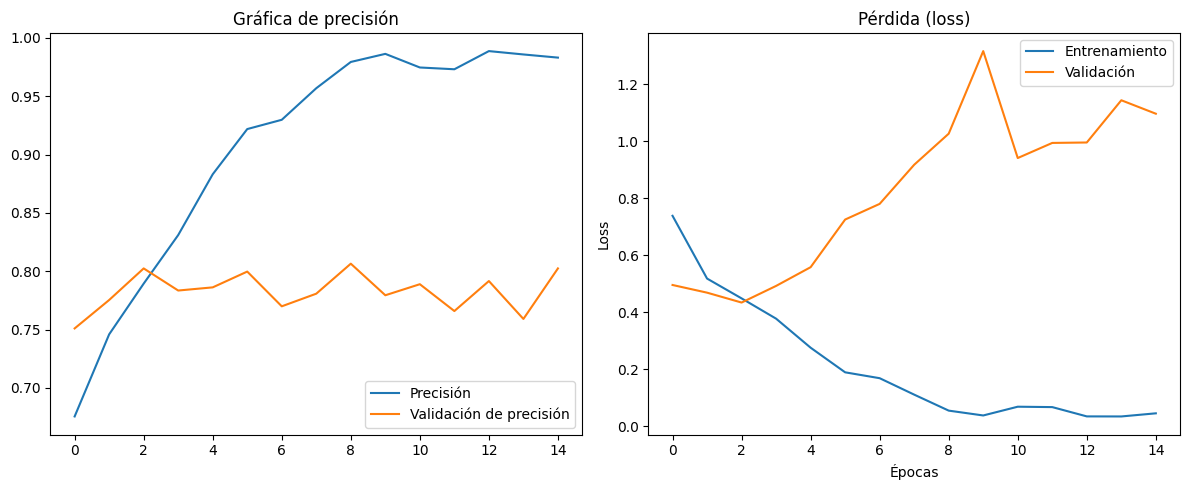

In [20]:
# Graficar resultados
acc = historial.history["accuracy"]
val_acc = historial.history["val_accuracy"]
loss = historial.history["loss"]
val_loss = historial.history["val_loss"]
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Gráfica de precisión
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Precisión")
plt.plot(epochs_range, val_acc, label="Validación de precisión")
plt.legend(loc="lower right")
plt.title("Gráfica de precisión")

# Gráfica de pérdida
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Entrenamiento")
plt.plot(epochs_range, val_loss, label="Validación")
plt.legend(loc="upper right")
plt.title("Pérdida (loss)")
plt.xlabel("Épocas")
plt.ylabel("Loss")

plt.tight_layout()
plt.show()

# Análisis de Resultados

Tenemos una precisión del 98.31%, iniciando el entrenamiento con una precisión del 67.56, incrementando en 15 epoch que se realizaron, esto utilizando el modelo **TANH**